# **CDACL-001-Automobile Insurance Complaints Rankings**

## Step 1: import libraries

In [4]:
#!pip install sqlalchemy pymysql 

In [15]:
#python -m pip install --upgrade pip

In [23]:
#!pip install sqlalchemy


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

#from sqlalchemy import create_engine

## Step 2:Load Dataset

In [24]:
df = pd.read_csv("./data/localhost.csv")

In [25]:
df.head()

,NAIC,Company_Name,Ratio,Upheld_Complaints,Question_of_Fact_Complaints,Not_Upheld_Complaints,Total_Complaints,Premiums_Written,Ranking,Filing_Year,FIELD11,FIELD12
0,32786,Progressive Specialty Insurance Company,0.0,0,17,29,46,204.173,1,2016,NaN,NaN
1,19976,Amica Mutual Insurance Company,0.0,0,9,8,17,84.769,2,2016,NaN,NaN
2,25453,Nationwide Insurance Company of America,0.0,0,9,4,13,65.335,3,2016,NaN,NaN
3,15024,Preferred Mutual Insurance Company,0.0,0,3,2,5,62.505,4,2016,NaN,NaN
4,10052,Chubb National Insurance Company,0.0,0,1,2,3,46.735,5,2016,NaN,NaN


In [26]:
# Check columns
df.columns

Index(['NAIC', 'Company_Name', 'Ratio', 'Upheld_Complaints',
       'Question_of_Fact_Complaints', 'Not_Upheld_Complaints',
       'Total_Complaints', 'Premiums_Written', 'Ranking', 'Filing_Year',
       'FIELD11', 'FIELD12'],
      dtype='object')

## Step 3:Data Cleaning

In [27]:
#Check missing values
df.isnull().sum()

NAIC                              0
Company_Name                      0
Ratio                             0
Upheld_Complaints                 0
Question_of_Fact_Complaints       0
Not_Upheld_Complaints             0
Total_Complaints                  0
Premiums_Written                  0
Ranking                           0
Filing_Year                       0
FIELD11                        1358
FIELD12                        1358
dtype: int64

In [28]:
# Remove unwanted columns
df = df.drop(columns=["FIELD11","FIELD12"])

In [29]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NAIC                         1358 non-null   int64  
 1   Company_Name                 1358 non-null   object 
 2   Ratio                        1358 non-null   float64
 3   Upheld_Complaints            1358 non-null   int64  
 4   Question_of_Fact_Complaints  1358 non-null   int64  
 5   Not_Upheld_Complaints        1358 non-null   int64  
 6   Total_Complaints             1358 non-null   int64  
 7   Premiums_Written             1358 non-null   float64
 8   Ranking                      1358 non-null   int64  
 9   Filing_Year                  1358 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 106.2+ KB


In [30]:
# Convert numeric columns
cols = [
'Ratio',
'Upheld_Complaints',
'Question_of_Fact_Complaints',
'Not_Upheld_Complaints',
'Total_Complaints',
'Premiums_Written',
'Ranking',
'Filing_Year'
]

df[cols] = df[cols].apply(pd.to_numeric)

## Step 4: Exploratory Data Analysis (EDA)

In [31]:
# Dataset shape
df.shape

(1358, 10)

In [32]:
# Summary
df.describe()

,NAIC,Ratio,Upheld_Complaints,Question_of_Fact_Complaints,Not_Upheld_Complaints,Total_Complaints,Premiums_Written,Ranking,Filing_Year
count,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000,1358.000000
mean,23936.145803,1.889557,3.104566,8.449190,14.896171,26.449926,64.379437,85.451399,2012.402798
std,9541.622447,38.291439,12.526851,33.353889,43.687174,84.382503,198.911112,49.305152,2.286526
min,10022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004000,1.000000,2009.000000
25%,16105.500000,0.000000,0.000000,0.000000,1.000000,2.000000,3.517500,43.000000,2010.000000
50%,23450.000000,0.016400,1.000000,1.000000,3.000000,6.000000,11.004000,85.000000,2012.000000
75%,29939.000000,0.106400,2.000000,5.000000,10.000000,17.000000,35.710000,128.000000,2014.000000
max,43974.000000,1364.877200,265.000000,698.000000,525.000000,1350.000000,2199.890000,181.000000,2016.000000


In [33]:
# Company count
df["Company_Name"].nunique()

223

## Step 5: Complaint Diagnostic Report

 A. Total Complaints

In [36]:



complaints = df.groupby("Company_Name")["Total_Complaints"].sum()

complaints.sort_values(ascending=False).head(10)

Company_Name
Allstate Insurance Company                          4949
GEICO General Insurance Company                     3898
Country-Wide Insurance Company                      3086
State Farm Mutual Automobile Insurance Company      2629
GEICO Indemnity Company                             2057
Government Employees Insurance Company              1797
Liberty Mutual Fire Insurance Company               1113
Allstate Property and Casualty Insurance Company     923
New York Central Mutual Fire Insurance Company       725
Progressive Casualty Insurance Company               682
Name: Total_Complaints, dtype: int64

Plot

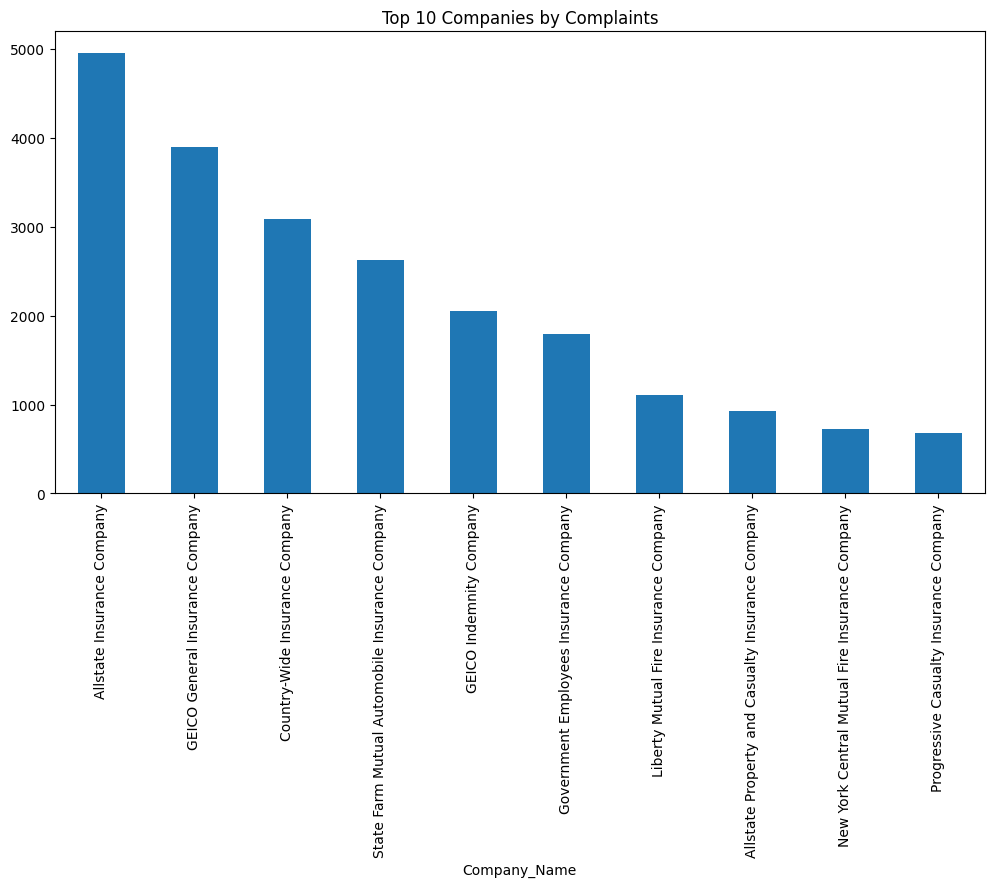

In [37]:


plt.figure(figsize=(12,6))

complaints.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Companies by Complaints")
plt.show()

B. Complaint Types

In [38]:
complaint_types = df[[
'Upheld_Complaints',
'Question_of_Fact_Complaints',
'Not_Upheld_Complaints'
]].sum()

Pie Chart

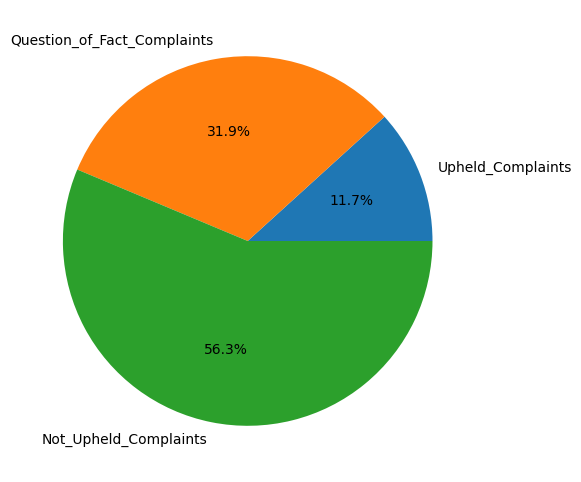

In [39]:
plt.figure(figsize=(6,6))

plt.pie(
complaint_types,
labels=complaint_types.index,
autopct="%1.1f%%"
)

plt.show()

C. Complaint Trend by Year

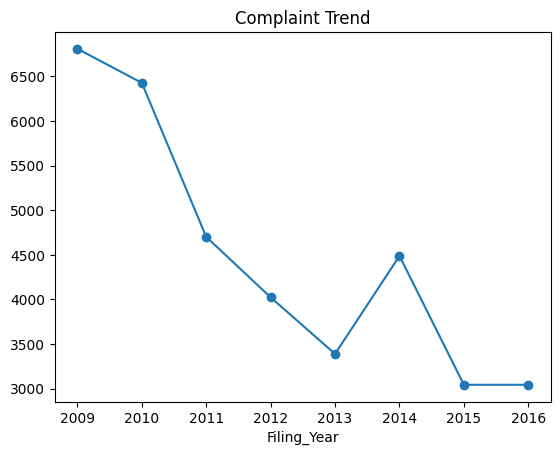

In [40]:
yearly = df.groupby("Filing_Year")["Total_Complaints"].sum()

yearly.plot(marker='o')
plt.title("Complaint Trend")
plt.show()

D. Company Improvement

In [41]:
# Find complaint ratio
ratio = df.groupby("Company_Name")["Ratio"].mean()

ratio.sort_values()

Company_Name
American Reliable Insurance Company                0.0000
Associated Indemnity Corporation                   0.0000
Amica Property and Casualty Insurance Company      0.0000
American Automobile Insurance Company              0.0000
Charter Oak Fire Insurance Company                 0.0000
                                                   ...   
Zurich American Insurance Company                 36.5845
Greater New York Mutual Insurance Company         74.5379
OneBeacon Insurance Company                      128.0041
Clarendon National Insurance Company             280.4459
New Hampshire Insurance Company                  455.3653
Name: Ratio, Length: 223, dtype: float64

Lowest ratio --> Best company --> Highest ratio --> Needs improvement

## Step 6: Premium Analysis

Premium by year

In [42]:
premium = df.groupby("Filing_Year")["Premiums_Written"].sum()

premium

Filing_Year
2009     9712.951
2010    10027.525
2011    10283.597
2012    10609.529
2013    10949.204
2014    11290.648
2015    12276.911
2016    12276.911
Name: Premiums_Written, dtype: float64

Plot

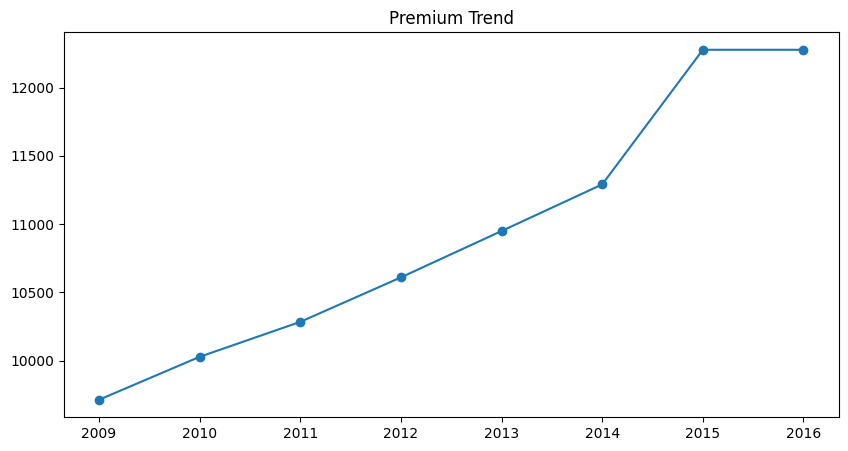

In [43]:
plt.figure(figsize=(10,5))

plt.plot(
premium.index,
premium.values,
marker='o'
)

plt.title("Premium Trend")
plt.show()

## Step 7: Compare Complaints vs Premium

In [44]:
company = df.groupby("Company_Name").agg({

"Premiums_Written":"sum",

"Total_Complaints":"sum"

}).reset_index()

Scatter plot

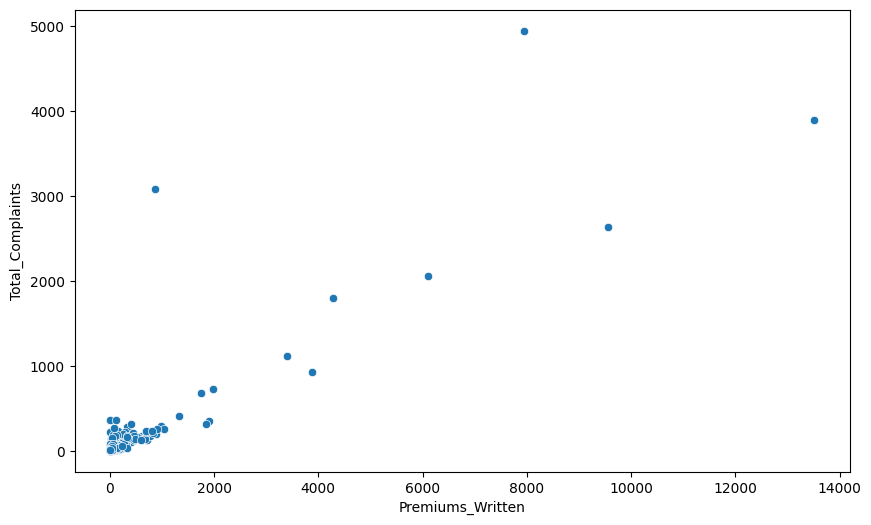

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
data=company,
x="Premiums_Written",
y="Total_Complaints"
)

plt.show()

## Step 8: Top 5 Companies Comparison

Top companies

In [46]:
top5 = df.groupby("Company_Name")["Premiums_Written"].sum().nlargest(5)

top5

Company_Name
GEICO General Insurance Company                   13514.383
State Farm Mutual Automobile Insurance Company     9557.517
Allstate Insurance Company                         7951.467
GEICO Indemnity Company                            6099.016
Government Employees Insurance Company             4281.047
Name: Premiums_Written, dtype: float64

Filter

In [47]:
compare = df[df.Company_Name.isin(top5.index)]

Premium comparison


<Axes: xlabel='Company_Name', ylabel='Premiums_Written'>

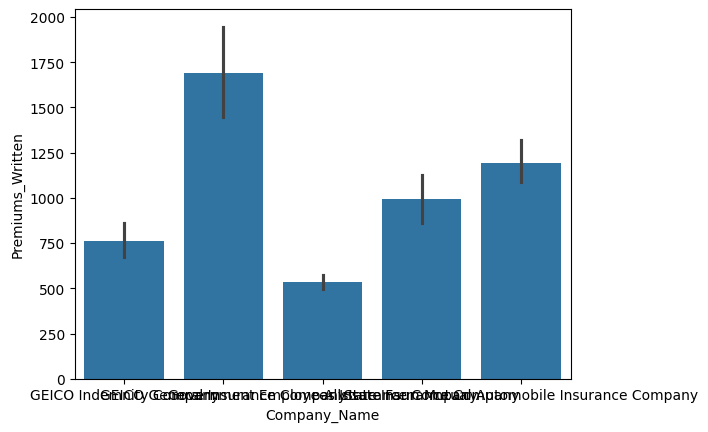

In [48]:
sns.barplot(
data=compare,
x="Company_Name",
y="Premiums_Written"
)

Complaint comparison

<Axes: xlabel='Company_Name', ylabel='Total_Complaints'>

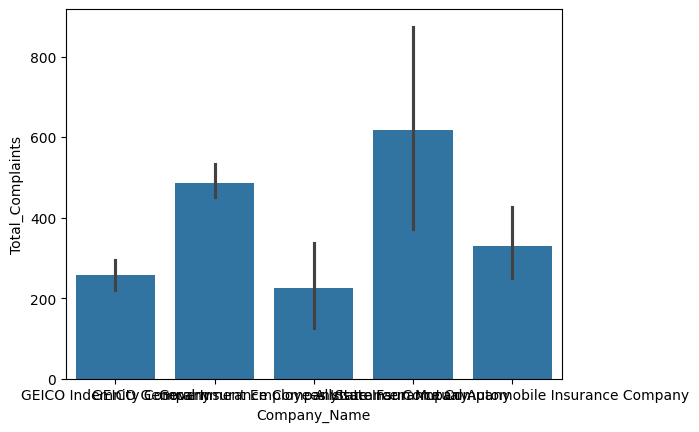

In [49]:
sns.barplot(
data=compare,
x="Company_Name",
y="Total_Complaints"
)

## Step 10: Dashboard (Python)

Using Plotly

In [50]:
fig = px.bar(
compare,
x="Company_Name",
y="Total_Complaints",
color="Company_Name"
)

fig.show()

Also create

- Complaint Trend
- Premium Trend
- Ranking Comparison
- Complaint Ratio
- Top 5 Companies

## Step 11: Future Premium Trend

Use Linear Regression

In [51]:
from sklearn.linear_model import LinearRegression

X = premium.index.values.reshape(-1,1)

y = premium.values

model = LinearRegression()

model.fit(X,y)

future = np.arange(
premium.index.min(),
premium.index.max()+3
).reshape(-1,1)

prediction = model.predict(future)

Plot

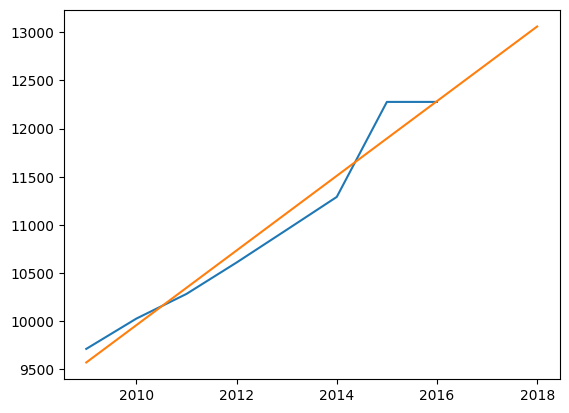

In [52]:
plt.plot(premium.index,premium.values)

plt.plot(future,prediction)

plt.show()

## Step 12: Insights

### Complaint Analysis

* **Allstate Insurance Company** recorded the **highest number of customer complaints** (4,949), making it the insurer with the largest complaint volume in the dataset.
* **GEICO General Insurance Company**, **Country-Wide Insurance Company**, and **State Farm Mutual Automobile Insurance Company** also ranked among the insurers with the highest complaint counts, indicating that these companies require close monitoring of customer service performance.
* The **"Not Upheld"** complaint category represents the largest share of complaints, suggesting that many reported issues were not substantiated after investigation.
* Complaint trends across **2009–2016** indicate that customer complaints remained concentrated among a small group of major insurers rather than being evenly distributed across all companies.
* Companies with higher complaint ratios should prioritize identifying recurring customer issues and improving complaint resolution processes.

### Premium Analysis

* Total premiums written showed a **steady upward trend from 2009 to 2016**, increasing from approximately **9,713** to **12,277**, reflecting consistent market growth.
* **GEICO General Insurance Company** generated the **highest premium volume**, followed by **State Farm Mutual Automobile Insurance Company** and **Allstate Insurance Company**, demonstrating their strong market presence.
* The positive premium trend suggests increased policy sales, business expansion, and a growing customer base throughout the analysis period.
* Higher premium volumes do not necessarily translate into better customer satisfaction, emphasizing the importance of evaluating complaint ratios alongside business performance.
* Comparing premiums with complaints helps identify insurers that successfully balance business growth with customer service quality.

### Recommendation

* **Allstate Insurance Company** and other insurers with high complaint volumes should improve claim settlement speed and customer communication to reduce complaint frequency.
* Companies with higher complaint ratios should perform root-cause analysis to identify recurring service issues and implement corrective actions.
* Simplifying the claims process and increasing transparency can improve customer satisfaction and reduce complaint escalation.
* Regularly monitor both **premium growth** and **complaint ratios** to ensure business expansion is supported by a positive customer experience.
* Use complaint analytics and trend monitoring to proactively address customer concerns before they impact company reputation.
